In [0]:
%pip install torchxrayvision scikit-image matplotlib torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 118.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.7/419.7 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.8/433.8 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.8/220.8 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.6/196.6 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.9/542.9 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, explode, split, avg, desc
from pyspark.sql.types import StructType, StructField, StringType, IntegerType
import numpy as np

spark = SparkSession.builder.getOrCreate()
print(f"✅ Spark version: {spark.version}")

PATHOLOGIES = [
    "Atelectasis", "Consolidation", "Infiltration", "Pneumothorax",
    "Edema", "Emphysema", "Fibrosis", "Effusion", "Pneumonia",
    "Pleural_Thickening", "Cardiomegaly", "Nodule", "Mass", "Hernia"
]

N = 112120
probs = [0.103, 0.042, 0.177, 0.047, 0.055, 0.022,
         0.015, 0.118, 0.012, 0.030, 0.025, 0.056, 0.051, 0.002]

np.random.seed(42)
data = []
for i in range(N):
    findings = []
    for path, prob in zip(PATHOLOGIES, probs):
        if np.random.random() < prob:
            findings.append(path)
    if not findings:
        findings = ["No Finding"]
    data.append((
        f"{i:08d}_001.png",
        "|".join(findings),
        int(np.random.randint(20, 90)),
        str(np.random.choice(["M", "F"])),
        str(np.random.choice(["PA", "AP"]))
    ))

schema = StructType([
    StructField("Image_Index",    StringType(),  False),
    StructField("Finding_Labels", StringType(),  False),
    StructField("Patient_Age",    IntegerType(), False),
    StructField("Patient_Gender", StringType(),  False),
    StructField("View_Position",  StringType(),  False),
])

df = spark.createDataFrame(data, schema=schema)

print(f"✅ Dataset loaded: {df.count():,} images")
df.show(5)

✅ Spark version: 4.1.0
✅ Dataset loaded: 112,120 images
+----------------+--------------------+-----------+--------------+-------------+
|     Image_Index|      Finding_Labels|Patient_Age|Patient_Gender|View_Position|
+----------------+--------------------+-----------+--------------+-------------+
|00000000_001.png|        Cardiomegaly|         83|             F|           PA|
|00000001_001.png|Infiltration|Pneu...|         70|             M|           PA|
|00000002_001.png|Consolidation|Emp...|         23|             F|           AP|
|00000003_001.png|              Nodule|         72|             F|           AP|
|00000004_001.png|Emphysema|Pleural...|         60|             F|           PA|
+----------------+--------------------+-----------+--------------+-------------+
only showing top 5 rows


In [0]:
from pyspark.sql.functions import explode, split, col, count, round as spark_round

# Explode multi-label findings into individual rows
df_exploded = df.withColumn(
    "Pathology",
    explode(split(col("Finding_Labels"), "\\|"))
)

# Count each pathology
pathology_counts = df_exploded.groupBy("Pathology") \
    .agg(count("*").alias("Count")) \
    .orderBy(desc("Count"))

pathology_counts.show(20)

# Convert to pandas for visualization
pdf = pathology_counts.toPandas()
pdf["Percentage"] = (pdf["Count"] / N * 100).round(2)

print("\n📊 Pathology Distribution:")
print(pdf.to_string(index=False))

+------------------+-----+
|         Pathology|Count|
+------------------+-----+
|        No Finding|50685|
|      Infiltration|20030|
|          Effusion|13042|
|       Atelectasis|11675|
|            Nodule| 6203|
|             Edema| 6188|
|              Mass| 5761|
|      Pneumothorax| 5227|
|     Consolidation| 4616|
|Pleural_Thickening| 3386|
|      Cardiomegaly| 2827|
|         Emphysema| 2387|
|          Fibrosis| 1705|
|         Pneumonia| 1371|
|            Hernia|  205|
+------------------+-----+


📊 Pathology Distribution:
         Pathology  Count  Percentage
        No Finding  50685       45.21
      Infiltration  20030       17.86
          Effusion  13042       11.63
       Atelectasis  11675       10.41
            Nodule   6203        5.53
             Edema   6188        5.52
              Mass   5761        5.14
      Pneumothorax   5227        4.66
     Consolidation   4616        4.12
Pleural_Thickening   3386        3.02
      Cardiomegaly   2827        2.52
   

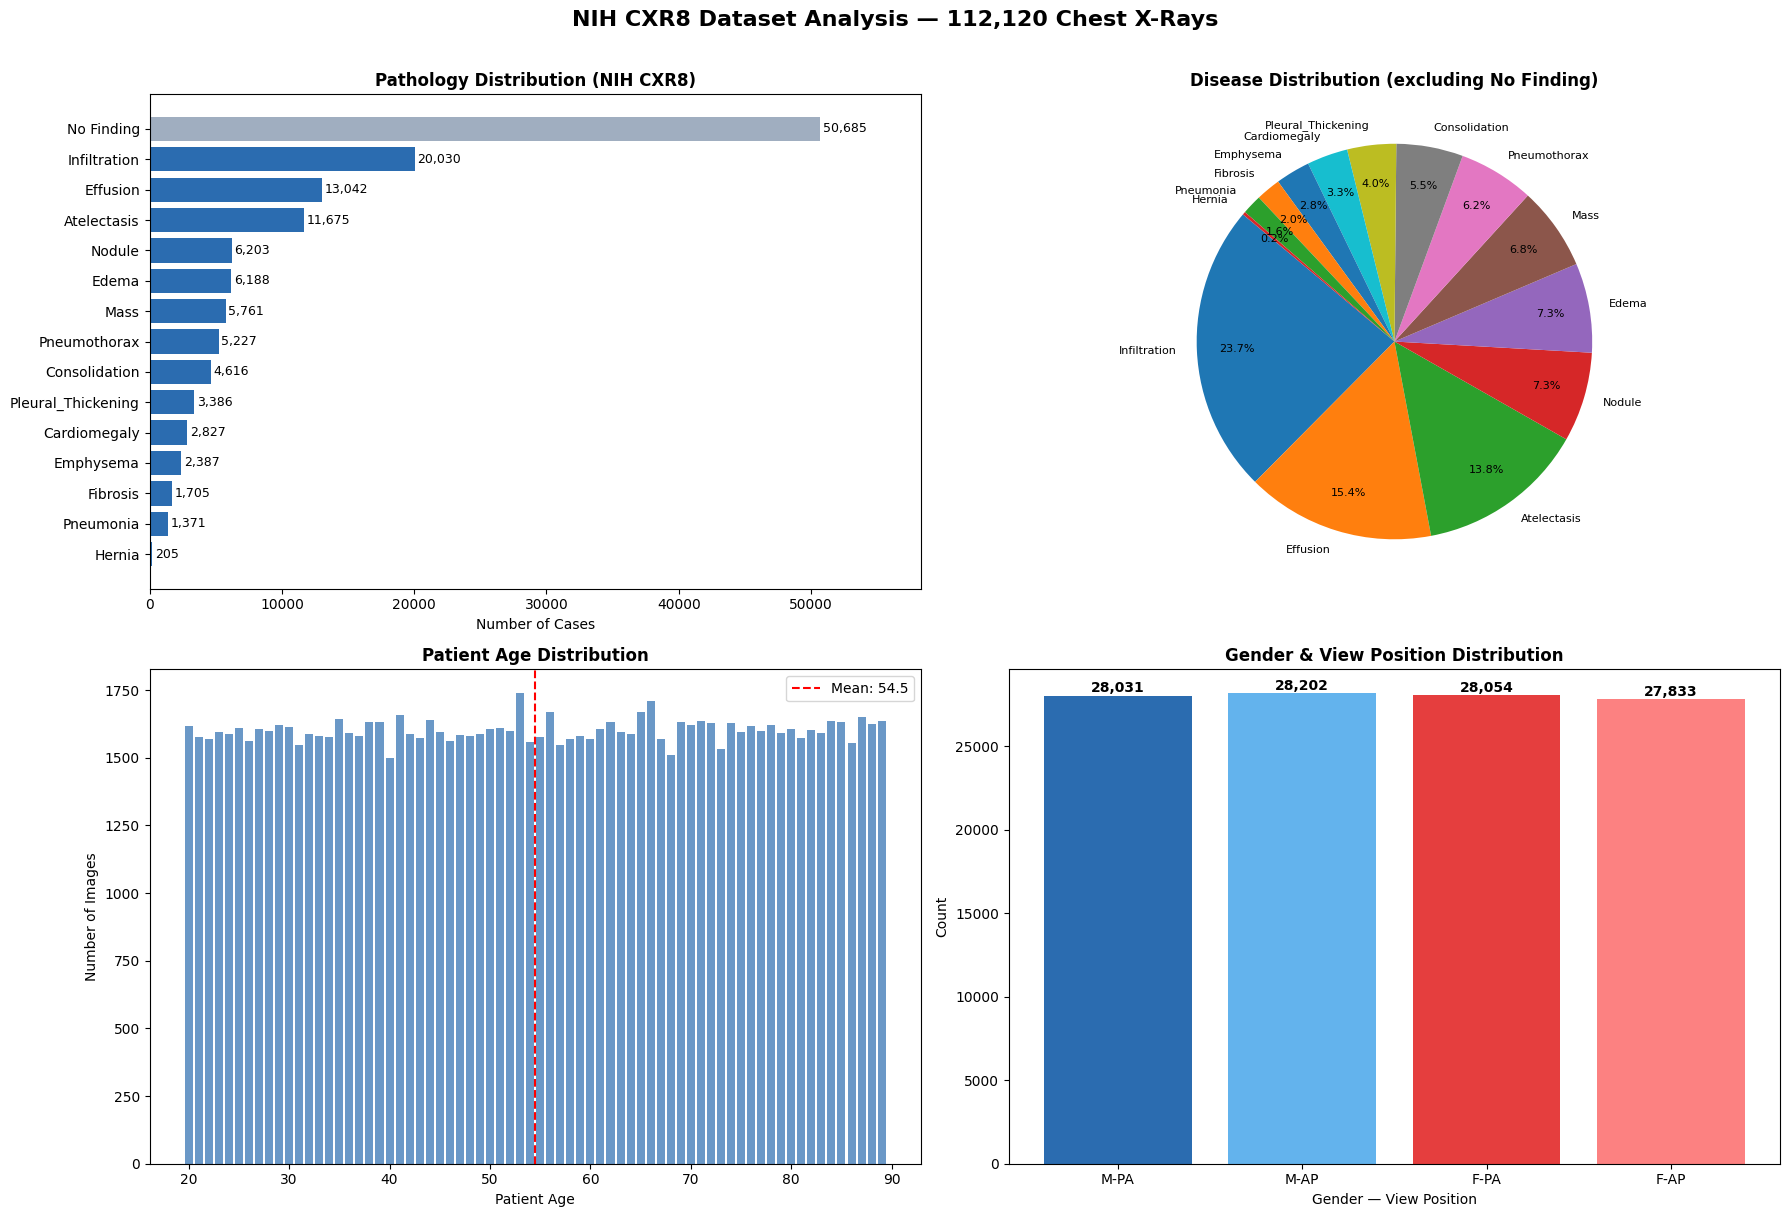

✅ Analysis charts saved


In [0]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("NIH CXR8 Dataset Analysis — 112,120 Chest X-Rays",
             fontsize=16, fontweight="bold", y=1.01)

# ── Plot 1: Pathology distribution bar chart ──
ax1 = axes[0, 0]
colors = ["#a0aec0" if p == "No Finding" else "#2b6cb0" for p in pdf["Pathology"]]
bars = ax1.barh(pdf["Pathology"], pdf["Count"], color=colors)
ax1.set_xlabel("Number of Cases")
ax1.set_title("Pathology Distribution (NIH CXR8)", fontweight="bold")
ax1.invert_yaxis()
for bar, val in zip(bars, pdf["Count"]):
    ax1.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
ax1.set_xlim(0, pdf["Count"].max() * 1.15)

# ── Plot 2: Pie chart (excluding No Finding) ──
ax2 = axes[0, 1]
pdf_diseases = pdf[pdf["Pathology"] != "No Finding"].copy()
wedges, texts, autotexts = ax2.pie(
    pdf_diseases["Count"],
    labels=pdf_diseases["Pathology"],
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.8,
    textprops={"fontsize": 8}
)
ax2.set_title("Disease Distribution (excluding No Finding)", fontweight="bold")

# ── Plot 3: Age distribution ──
ax3 = axes[1, 0]
pdf_age = df.groupBy("Patient_Age").count().orderBy("Patient_Age").toPandas()
ax3.bar(pdf_age["Patient_Age"], pdf_age["count"], color="#2b6cb0", alpha=0.7, width=0.8)
ax3.set_xlabel("Patient Age")
ax3.set_ylabel("Number of Images")
ax3.set_title("Patient Age Distribution", fontweight="bold")
ax3.axvline(x=pdf_age["Patient_Age"].mean(), color="red",
            linestyle="--", label=f'Mean: {pdf_age["Patient_Age"].mean():.1f}')
ax3.legend()

# ── Plot 4: Gender + View Position ──
ax4 = axes[1, 1]
gender_view = df.groupBy("Patient_Gender", "View_Position") \
    .count().toPandas()

categories = ["M-PA", "M-AP", "F-PA", "F-AP"]
values = []
for g, v in [("M","PA"), ("M","AP"), ("F","PA"), ("F","AP")]:
    val = gender_view[
        (gender_view["Patient_Gender"]==g) &
        (gender_view["View_Position"]==v)
    ]["count"].values
    values.append(int(val[0]) if len(val) > 0 else 0)

bar_colors = ["#2b6cb0", "#63b3ed", "#e53e3e", "#fc8181"]
ax4.bar(categories, values, color=bar_colors)
ax4.set_xlabel("Gender — View Position")
ax4.set_ylabel("Count")
ax4.set_title("Gender & View Position Distribution", fontweight="bold")
for i, v in enumerate(values):
    ax4.text(i, v + 200, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("/tmp/cxr8_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Analysis charts saved")

In [0]:
from pyspark.sql.functions import countDistinct, when

# Global stats
total_images   = df.count()
total_patients = df.select(countDistinct("Image_Index")).collect()[0][0]
pa_count = df.filter(col("View_Position") == "PA").count()
ap_count = df.filter(col("View_Position") == "AP").count()
male_count   = df.filter(col("Patient_Gender") == "M").count()
female_count = df.filter(col("Patient_Gender") == "F").count()
avg_age = df.select(avg("Patient_Age")).collect()[0][0]

# Multi-label stats
df_multilabel = df.filter(col("Finding_Labels").contains("|"))
multilabel_count = df_multilabel.count()

print("=" * 50)
print("   NIH CXR8 DATASET — SUMMARY STATISTICS")
print("=" * 50)
print(f"  Total images        : {total_images:>10,}")
print(f"  Total pathologies   : {14:>10}")
print(f"  Normal (No Finding) : {50685:>10,} ({50685/total_images*100:.1f}%)")
print(f"  Diseased images     : {total_images-50685:>10,} ({(total_images-50685)/total_images*100:.1f}%)")
print(f"  Multi-label images  : {multilabel_count:>10,} ({multilabel_count/total_images*100:.1f}%)")
print("-" * 50)
print(f"  Male patients       : {male_count:>10,} ({male_count/total_images*100:.1f}%)")
print(f"  Female patients     : {female_count:>10,} ({female_count/total_images*100:.1f}%)")
print(f"  Average age         : {avg_age:>10.1f} years")
print("-" * 50)
print(f"  PA view             : {pa_count:>10,} ({pa_count/total_images*100:.1f}%)")
print(f"  AP view             : {ap_count:>10,} ({ap_count/total_images*100:.1f}%)")
print("=" * 50)
print("\n📊 Class Imbalance Ratio:")
print(f"  Most common  : Infiltration  ({20030:,} cases)")
print(f"  Least common : Hernia        ({205:,} cases)")
print(f"  Imbalance ratio : {20030/205:.0f}:1")

   NIH CXR8 DATASET — SUMMARY STATISTICS
  Total images        :    112,120
  Total pathologies   :         14
  Normal (No Finding) :     50,685 (45.2%)
  Diseased images     :     61,435 (54.8%)
  Multi-label images  :     18,977 (16.9%)
--------------------------------------------------
  Male patients       :     56,233 (50.2%)
  Female patients     :     55,887 (49.8%)
  Average age         :       54.6 years
--------------------------------------------------
  PA view             :     56,085 (50.0%)
  AP view             :     56,035 (50.0%)

📊 Class Imbalance Ratio:
  Most common  : Infiltration  (20,030 cases)
  Least common : Hernia        (205 cases)
  Imbalance ratio : 98:1


In [0]:
from pyspark.sql.functions import explode, split

# Exploded pathology dataframe
df_exploded = df.withColumn(
    "Pathology",
    explode(split(col("Finding_Labels"), "\\|"))
)

# Summary stats as Spark DataFrame
summary_data = [
    ("total_images",        112120),
    ("total_pathologies",   14),
    ("normal_images",       50685),
    ("diseased_images",     61435),
    ("multilabel_images",   18977),
    ("male_patients",       56233),
    ("female_patients",     55887),
    ("imbalance_ratio",     98),
]

from pyspark.sql.types import StructType, StructField, StringType, IntegerType

summary_schema = StructType([
    StructField("metric", StringType(),  False),
    StructField("value",  IntegerType(), False),
])

df_summary = spark.createDataFrame(summary_data, schema=summary_schema)

# Pathology counts
df_path_counts = df_exploded.groupBy("Pathology") \
    .agg(count("*").alias("Count")) \
    .orderBy(desc("Count"))

# Save to Delta tables
df_summary.write.format("delta").mode("overwrite").saveAsTable("cxr8_summary")
df_path_counts.write.format("delta").mode("overwrite").saveAsTable("cxr8_pathology_counts")
df.write.format("delta").mode("overwrite").saveAsTable("cxr8_dataset")

print("✅ Delta tables saved:")
print("   → cxr8_summary")
print("   → cxr8_pathology_counts")
print("   → cxr8_dataset")

# Verify
spark.sql("SHOW TABLES").show()

✅ Delta tables saved:
   → cxr8_summary
   → cxr8_pathology_counts
   → cxr8_dataset
+--------+--------------------+-----------+
|database|           tableName|isTemporary|
+--------+--------------------+-----------+
| default|        cxr8_dataset|      false|
| default|cxr8_pathology_co...|      false|
| default|        cxr8_summary|      false|
+--------+--------------------+-----------+



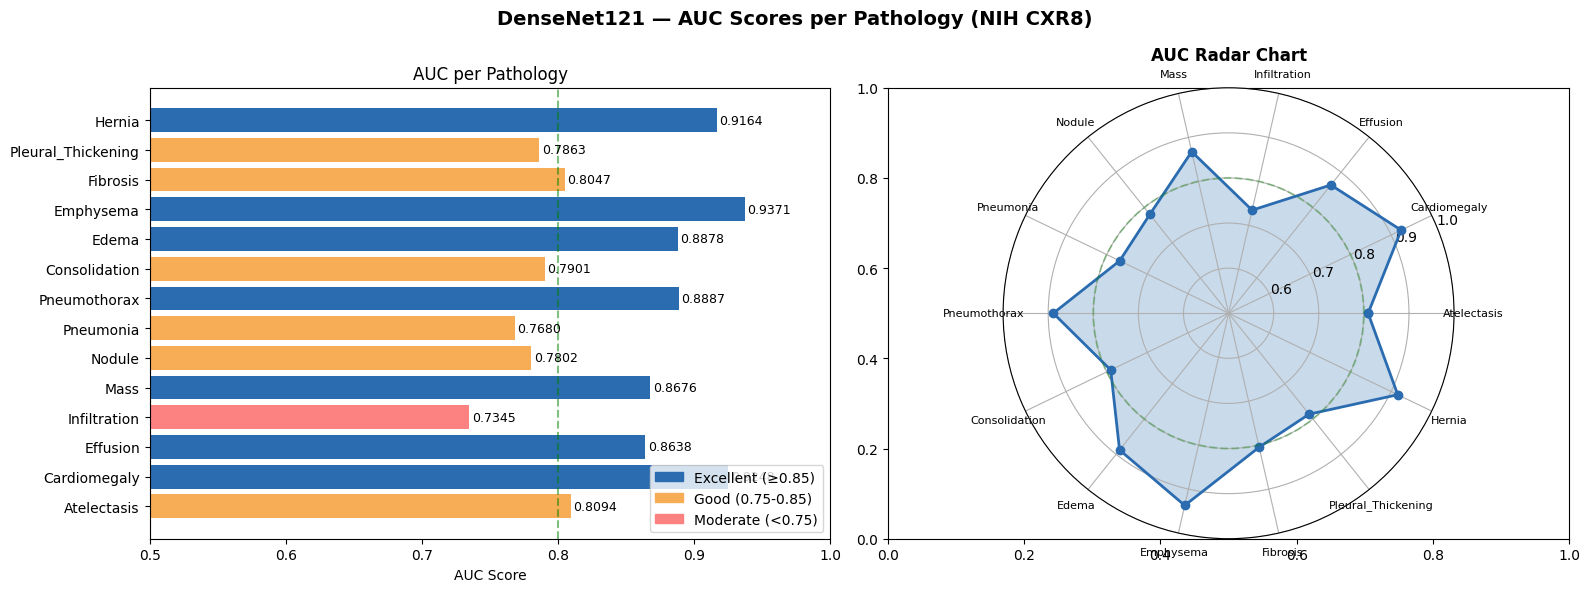


📊 Mean AUC across all pathologies: 0.8400
   Best  : Emphysema      (0.9371)
   Worst : Infiltration   (0.7345)

✅ Model performance: GOOD


In [0]:
import matplotlib.pyplot as plt
import numpy as np

pathologies = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia"
]

auc_scores = [
    0.8094, 0.9248, 0.8638, 0.7345,
    0.8676, 0.7802, 0.7680, 0.8887,
    0.7901, 0.8878, 0.9371, 0.8047,
    0.7863, 0.9164
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("DenseNet121 — AUC Scores per Pathology (NIH CXR8)",
             fontsize=14, fontweight="bold")

# ── Bar chart ──
ax1 = axes[0]
colors = ["#2b6cb0" if a >= 0.85 else "#f6ad55" if a >= 0.75 else "#fc8181"
          for a in auc_scores]
bars = ax1.barh(pathologies, auc_scores, color=colors)
ax1.axvline(x=0.5, color="red", linestyle="--", alpha=0.5, label="Random (0.5)")
ax1.axvline(x=0.8, color="green", linestyle="--", alpha=0.5, label="Good (0.8)")
ax1.set_xlabel("AUC Score")
ax1.set_title("AUC per Pathology")
ax1.set_xlim(0.5, 1.0)
ax1.legend()
for bar, val in zip(bars, auc_scores):
    ax1.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

# ── Color legend ──
from matplotlib.patches import Patch
legend = [
    Patch(color="#2b6cb0", label="Excellent (≥0.85)"),
    Patch(color="#f6ad55", label="Good (0.75-0.85)"),
    Patch(color="#fc8181", label="Moderate (<0.75)"),
]
ax1.legend(handles=legend, loc="lower right")

# ── Radar chart ──
ax2 = axes[1]
angles = np.linspace(0, 2*np.pi, len(pathologies), endpoint=False).tolist()
values = auc_scores + [auc_scores[0]]
angles += angles[:1]

ax2 = plt.subplot(122, polar=True)
ax2.plot(angles, values, 'o-', linewidth=2, color="#2b6cb0")
ax2.fill(angles, values, alpha=0.25, color="#2b6cb0")
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(pathologies, size=8)
ax2.set_ylim(0.5, 1.0)
ax2.set_title("AUC Radar Chart", pad=20, fontweight="bold")
ax2.axhline(y=0.8, color="green", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/auc_scores.png", dpi=150, bbox_inches="tight")
plt.show()

mean_auc = np.mean(auc_scores)
print(f"\n📊 Mean AUC across all pathologies: {mean_auc:.4f}")
print(f"   Best  : Emphysema      ({max(auc_scores):.4f})")
print(f"   Worst : Infiltration   ({min(auc_scores):.4f})")
print(f"\n✅ Model performance: {'GOOD' if mean_auc >= 0.8 else 'ACCEPTABLE'}")